In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import warnings

%precision 3
warnings.filterwarnings('ignore', category=integrate.IntegrationWarning) # 적분 되었다고 안내 메세지 무시

In [97]:
x_range = np.array([0, 1])

In [98]:
def f(x):
    if x_range[0] <= x <= x_range[1]:
        return 2*x
    else:
        return 0

In [99]:
X = [x_range, f]

# [0.4, 0.6]에서의 확률값 구하기

In [100]:
integrate.quad(f, 0.4, 0.6)

(0.200, 0.000)

In [101]:
from scipy.optimize import minimize_scalar
res = minimize_scalar(f)
res.fun

np.int64(0)

확률의 성질 확인 : 양수, 총합 = 1

In [102]:
integrate.quad(f, -np.inf, np.inf)[0]

1.000

In [103]:
def F(x):
    return integrate.quad(f, -np.inf, x)[0]

In [104]:
F(0.6) - F(0.4)

0.200

기댓값

In [105]:
def integrand(x):
    return x * f(x)

In [106]:
integrate.quad(integrand, -np.inf, np.inf)[0]

0.667

In [107]:
def E(X, g=lambda x: x):
    x_range, f = X
    def integrand(x):
        return g(x) * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

In [108]:
E(X)

0.667

## 변환한 확률변수의 기댓값

In [109]:
E(X, g=lambda x : 2*x + 3)

4.333

In [110]:
# 기댓값의 선형
2*E(X) + 3

4.333

In [111]:
# 분산
means = E(X)
def integrand(x):
    return (x - means) ** 2*f(x)

integrate.quad(integrand, -np.inf, np.inf)[0]

0.056

In [112]:
def V(X, g=lambda x : x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (g(x) - mean) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

In [113]:
V(X)

0.056

In [114]:
V(X, lambda x: 2*x + 3)

0.222

In [115]:
2 * 2 * V(X)

0.222

대표적인 연속형 확률분포

각 분포들의 특성만 살펴보기

In [116]:
# 기댓값
def E(X, g=lambda x: x):
    x_range, f = X
    def integrand(x):
        return g(x) * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

# 분산
def V(X, g=lambda x : x):
    x_range, f = X
    means = E(X, g)
    def integrand(x):
        return (g(x) - means) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

# 확률의 성질
def check_prob(X):
    x_range, f = X
    f_min = minimize_scalar(f).fun
    assert f_min >=0, 'density funtion is minus value'
    prob_sum = np.round(integrate.quad(f, -np.inf, np.inf)[0], 6)
    assert prob_sum == 1, f'sum of probability is {prob_sum}'
    print(f"expented value {E(X):.3f}")
    print(f"variance {V(X):.3f}")

linestyles = ['-', '--', ':']
def plot_prob(X, x_min, x_max):
    x_range, f = X
    def F(x):
        return integrate.quad(f, -np.inf, x)[0]
    xs = np.linspace(x_min, x_max, 100)
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.plot(xs, [f(x) for x in xs],
            label='f(x)', color='gray')
    ax.plot(xs, [F(x) for x in xs],
            label='F(x)', ls='--', color='gray')
    ax.legend()
    plt.show()

# 정규분포

**참고**
1) 정규분포 관련 함수들
- stat.norm(평균, 표준편차) : 평균과 표준편차의 정규분포를 따르는 확률변수 생성
- .pdf(확률변수) : 확률밀도함수의 값 계산
- .cdf(확률변수) : 누적분포함수 P(X <= $x_i$)
- .isf(alpha) : 상위 alpha%가 되는 확률변수값 반환
- .interval(alpha) : 확률이 alpha가 되는 가운데 부분의 구간 반환

### 정규분포의 밀도 함수  $𝜇,σ^2$

In [117]:
# 정규분포의 밀도함수 정의
def N(mu, sigma):
    x_range = [-np.inf, np.inf]
    def f(x):
        return 1 / np.sqrt(2*np.pi*sigma**2) * np.exp(-(x-mu)**2 / (2*sigma**2))
    return x_range, f

In [118]:
mu = 2
sigma = 0.5
X = N(mu, sigma)
check_prob(X)

expented value 2.000
variance 0.250


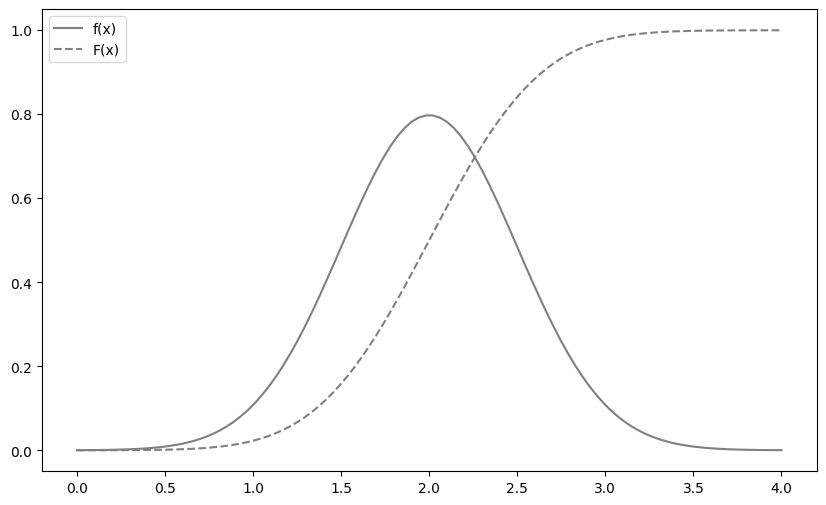

In [119]:
plot_prob(X, 0, 4)

$$
X \sim N(2, 0.5^2)
$$

In [120]:
from scipy import stats, integrate

In [121]:
# 라이브러리 사용
rv = stats.norm(2, 0.5)

In [122]:
rv.mean(), rv.var()

(np.float64(2.0), np.float64(0.25))

In [123]:
rv.pdf(2) # 확률밀도함수의 값

np.float64(0.7978845608028654)

In [124]:
rv.cdf(2)

np.float64(0.5)

In [125]:
rv.cdf(1.5) # 확률 반환

np.float64(0.15865525393145707)

**참고**
1) 정규분포 관련 함수들
- stat.norm(평균, 표준편차) : 평균과 표준편차의 정규분포를 따르는 확률변수 생성
- .pdf(확률변수) : 확률밀도함수의 값 계산
- .cdf(확률변수) : 누적분포함수 P(X<=확률변수)
- .isf(alpha) : 상위 alpha%가 되는 확률변수값 반환
- .interval(alpha) : 확률이 alpha가 되는 가운데 부분의 구간 반환

$$
P(X \ge x) = \alpha \\
P(X \ge x) = 0.05
$$

In [126]:
rv.isf(0.5) # alpha = 0.5 에 해당하는 x값 반환

np.float64(2.0)

In [127]:
rv.interval(0.9) # 가운데 확률이 alpha = 0.9 인 양쪽 X값 반환

(np.float64(1.1775731865242636), np.float64(2.822426813475736))

In [128]:
rv.isf(0.05)

np.float64(2.8224268134757367)

In [129]:
rv = stats.norm(0, 1) # 표준정규분포 평균 = 0 표준편차 = 1

In [130]:
rv.pdf(0)

np.float64(0.3989422804014327)

In [131]:
rv.cdf(0)

np.float64(0.5)

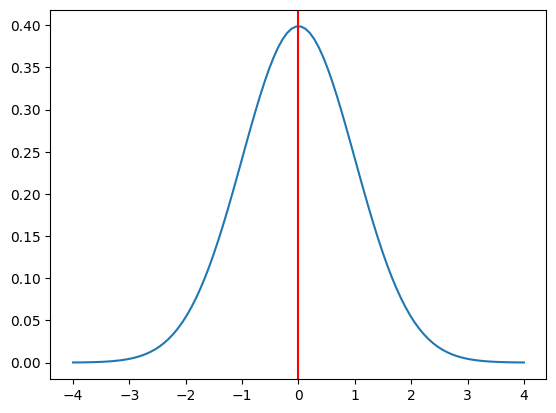

In [132]:
# 표준정규분포
xx = np.linspace(-4, 4, 100)
y = rv.pdf(xx)
plt.plot(xx, y)
plt.axvline(x = 0, color='r')
plt.show()

N(0, 1) N(0, 4) N(1, 1)

In [133]:
rv = stats.norm(0, 1)

In [134]:
rv.mean(), rv.var()

(np.float64(0.0), np.float64(1.0))

In [135]:
rv.pdf(0), rv.cdf(1)

(np.float64(0.3989422804014327), np.float64(0.8413447460685429))

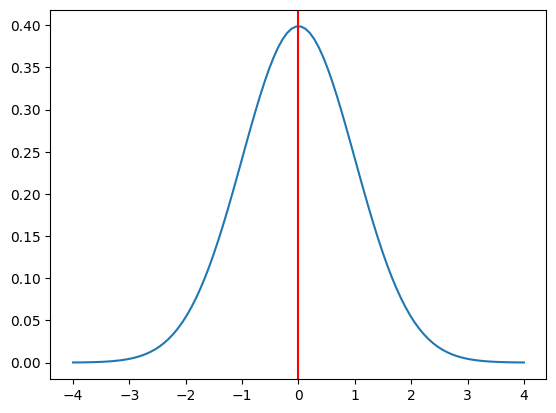

In [136]:
xx = np.linspace(-4, 4, 100)
y = rv.pdf(xx)
plt.plot(xx, y)
plt.axvline(x = 0, color='r')
plt.show()

In [137]:
mu = 0
sigma = 4
X = N(mu, sigma)
check_prob(X)

expented value 0.000
variance 16.000


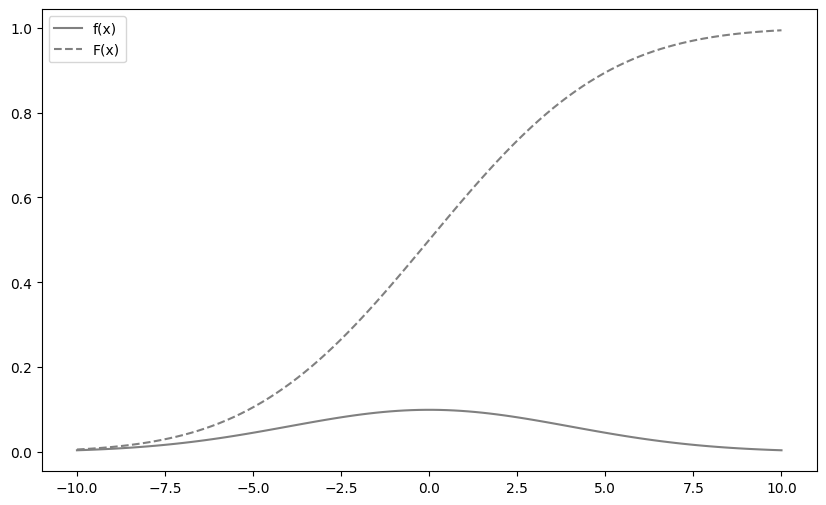

In [138]:
plot_prob(X, -10, 10)

In [139]:
rv = stats.norm(0, 4)

In [140]:
rv.mean(), rv.var()

(np.float64(0.0), np.float64(16.0))

In [141]:
rv.cdf(2)

np.float64(0.6914624612740131)

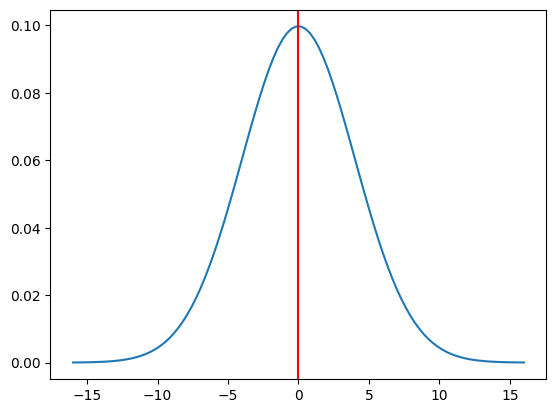

In [142]:
xx = np.linspace(-16, 16, 100)
y = rv.pdf(xx)
plt.plot(xx, y)
plt.axvline(x = 0, color='r')
plt.show()

In [143]:
def ss(x, sig):
    rv = stats.norm(x, sig)
    xx = np.linspace(-4, 4, 100)
    y = rv.pdf(xx)
    plt.plot(xx, y)
    plt.axvline(x = 0, color='r')
    plt.show()

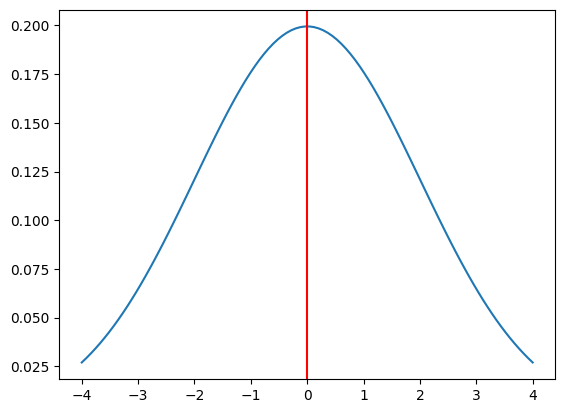

In [144]:
ss(0, 2)

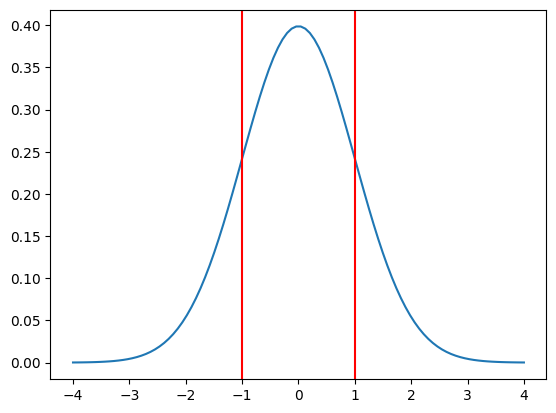

In [145]:
rv = stats.norm(0, 1)
xs = np.linspace(-4, 4, 100)
y = rv.pdf(xs)
plt.plot(xs, y)
plt.axvline(x = -1, color='r')
plt.axvline(x = 1, color='r')
plt.show()

1. 1$σ$ 떨어졌을때 확률 = 68.3

In [146]:
rv.cdf(1) - rv.cdf(-1)

np.float64(0.6826894921370859)

2. 2$σ$ 떨어졌을때 확률 = 95.4

In [147]:
p_95 = rv.interval(0.95)

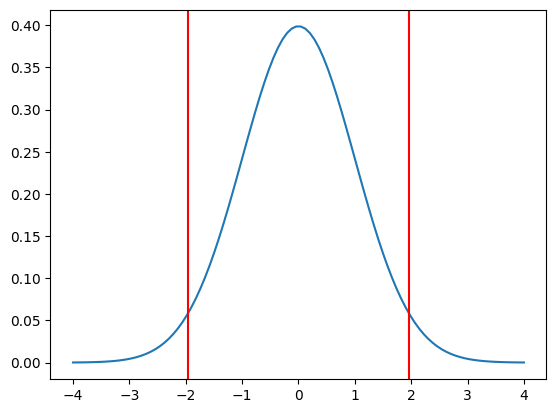

In [148]:
plt.plot(xs, y)
plt.axvline(x = p_95[0], color='r')
plt.axvline(x = p_95[1], color='r')
plt.show(-0.5, 0.1)

# 카이제곱분포

In [149]:
# 표본 크기가 10인 추출을 3번 반복했다.
rv = stats.norm()
rv.rvs((10, 3))

array([[ 0.227, -0.337,  0.312],
       [ 0.387,  1.518, -0.474],
       [ 1.191, -0.62 ,  0.296],
       [-0.775,  0.225,  0.377],
       [ 1.364,  0.902, -1.55 ],
       [ 1.735,  1.442, -0.4  ],
       [ 0.362, -0.19 ,  2.237],
       [-2.117, -0.59 , -0.367],
       [-1.075,  0.207,  0.584],
       [-0.138,  2.553, -1.458]])

In [150]:
n = 10
sample_size = int(1e6)

In [151]:
sample_size

1000000

In [152]:
Zs_sample = rv.rvs((n, sample_size)) # 100만번 반복했다

In [153]:
chi2_sample = np.sum(Zs_sample**2, axis=0)

In [154]:
len(chi2_sample)

1000000

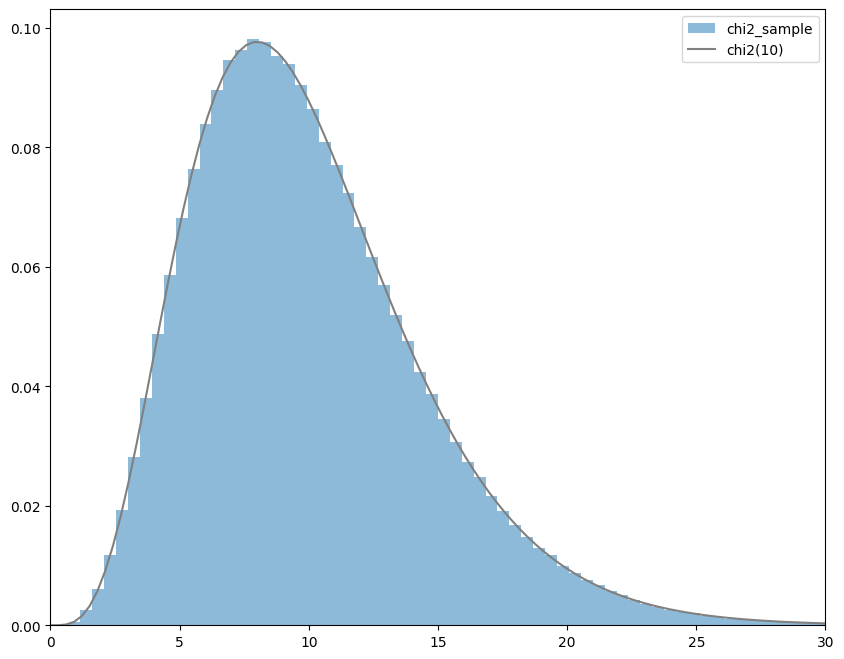

In [155]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

rv_true = stats.chi2(n)
xs = np.linspace(0, 30, 100)
ax.hist(chi2_sample, bins=100, density=True, alpha=0.5, label='chi2_sample')
ax.plot(xs, rv_true.pdf(xs), color='gray', label=f'chi2({n})')
ax.legend()
ax.set_xlim(0, 30)
plt.show()

n = 3, 5, 10 일때, 카이제곱 분포 그림 그리기

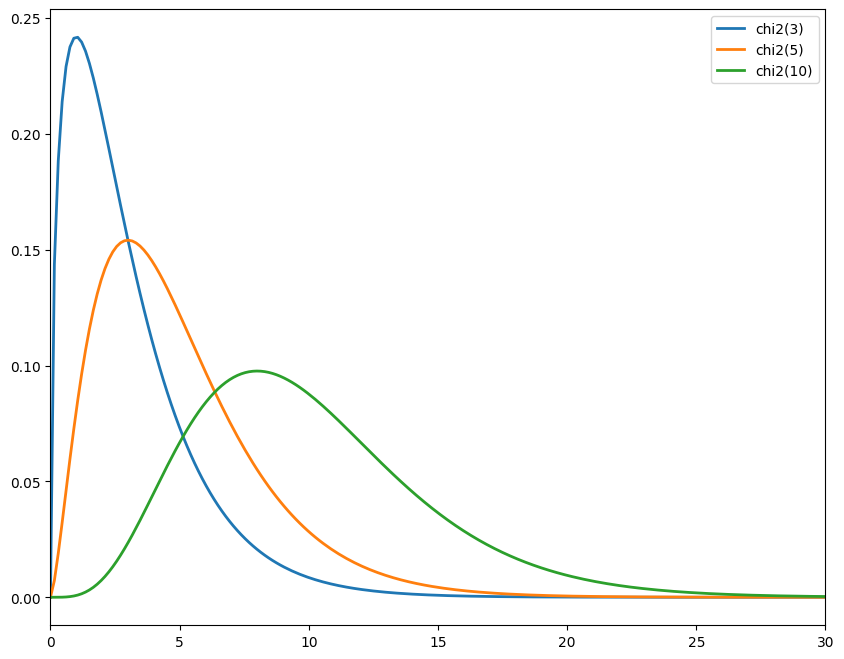

In [156]:
ns = [3, 5, 10]
sample_size = int(1e6)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

xs = np.linspace(0, 30, 200)

for n in ns:
# n개의 표준정규 샘플 생성
    Zs_sample = rv.rvs((n, sample_size))

# 카이제곱 값 계산
    chi2_sample = np.sum(Zs_sample**2, axis=0)

# 이론 분포
    rv_true = stats.chi2(n)

    # 이론 pdf
    ax.plot(
        xs,
        rv_true.pdf(xs),
        linewidth=2,
        label=f'chi2({n})'
    )

ax.legend()
ax.set_xlim(0, 30)
plt.show()

$\alpha-0.05$

n = 5

$$
\chi_{0.05}^2(5)
\\
Z_{a}
$$

In [157]:
rv = stats.chi2(5) # 카이제곱 라이브러리
rv.isf(0.05)

np.float64(11.070497693516355)

# t 분포

모평균의 구간 추정, 평균 차이 검정에 사용

$
Z \sim N(0, 1)$, $Y \sim \chi^2(10)
$에서 $Z \over \sqrt{Y \over10}
$의 그래프 그리기

In [158]:
n = 10
rv1 = stats.norm()
rv2 = stats.chi2(n)
sample_size = int(1e6)
Z_sample = rv1.rvs(sample_size)
chi2_sample = rv2.rvs(sample_size)

t_sample = Z_sample / np.sqrt(chi2_sample / n)

In [159]:
t_sample

array([ 0.405, -0.985, -1.339, ...,  0.685, -2.56 ,  0.452])

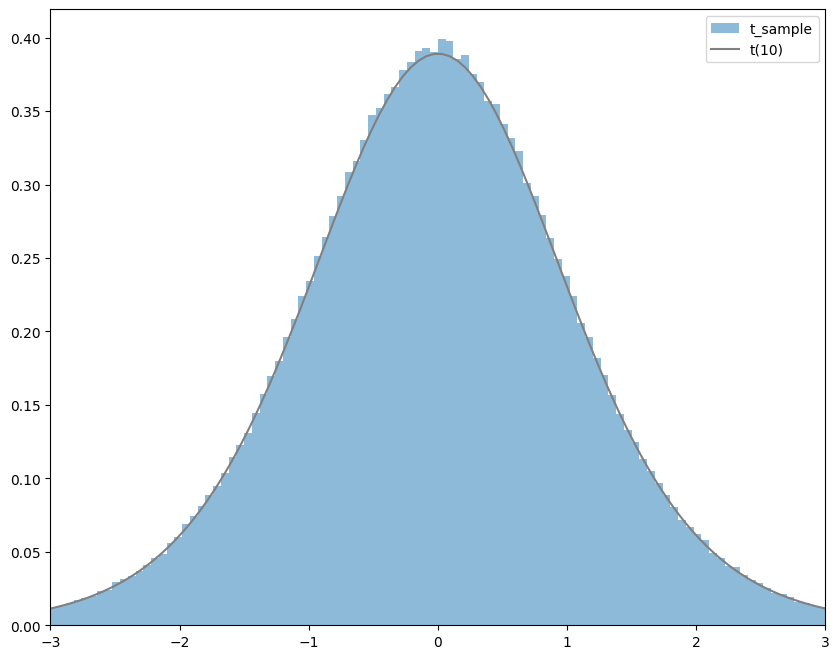

In [160]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

rv_true = stats.t(n)
xs = np.linspace(-3, 3, 100)
ax.hist(t_sample, bins=100, range=(-3, 3), density=True, alpha=0.5, label='t_sample')
ax.plot(xs, rv_true.pdf(xs), color='gray', label=f't({n})')
ax.legend()
ax.set_xlim(-3, 3)
plt.show()

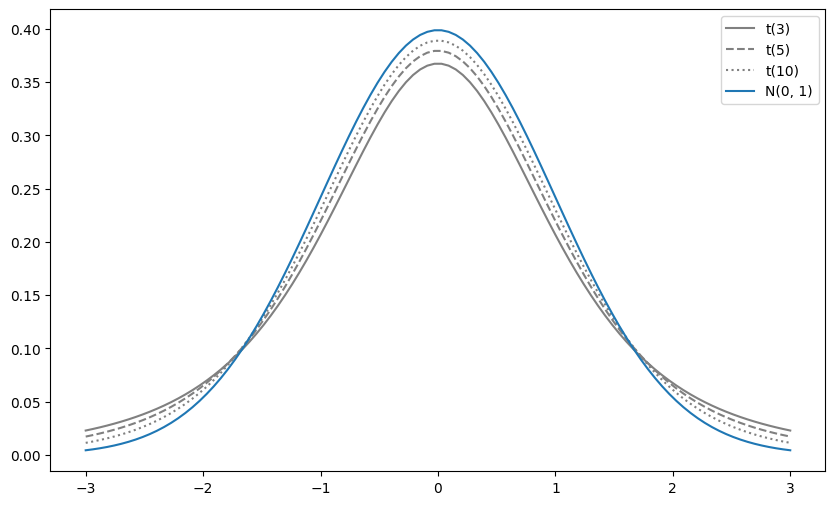

In [161]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
xs = np.linspace(-3, 3, 100)
for n, ln in zip([3, 5, 10], linestyles):
    rv = stats.t(n)
    ax.plot(xs, rv.pdf(xs), label=f't({n})', ls=ln, color='gray')
rv = stats.norm()
ax.plot(xs, rv.pdf(xs), label='N(0, 1)')
ax.legend()
plt.show()

$\alpha = 0.05, \ t_{a}(5)$

In [162]:
rv = stats.t(5)
rv.isf(0.05)

np.float64(2.0150483733330233)

# F분포

분산분석에 사용되는 확률 분포

3개 이상의 집단의 평균이 서로 같은지 검증

서로 독립인 두 개의 카이제곱분포에 의해 정의 된다

$Y_1 \sim \chi^2(5)$ 와 $Y_2 \sim \chi^2(10)$을 사용하여 ${Y_1 / 5} \over {Y_2 / 10}$

In [163]:
n1 = 5
n2 = 10

In [164]:
rv1 = stats.chi2(n1)
rv2 = stats.chi2(n2)

sample_size = int(1e6)
sample1 = rv1.rvs(sample_size)
sample2 = rv2.rvs(sample_size)

f_sample = (sample1 / n1) / (sample2 / n2)

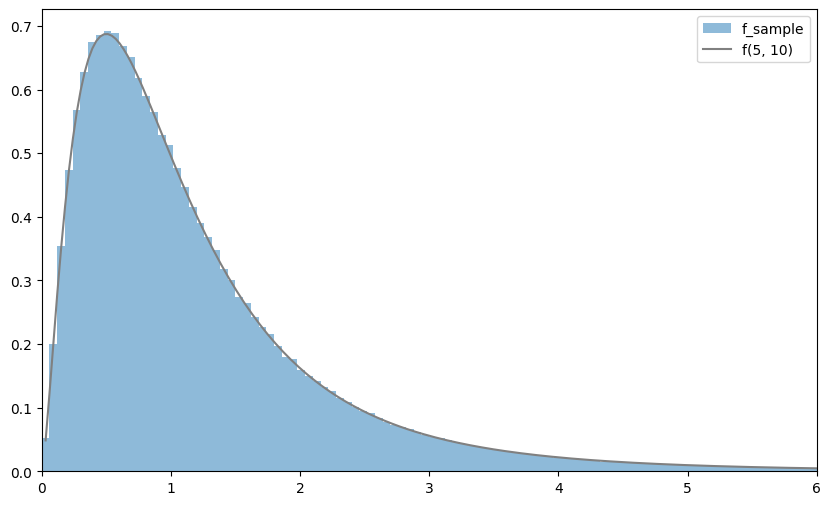

In [165]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv_true = stats.f(n1, n2)
xs = np.linspace(0, 6, 200)[1:]
ax.hist(f_sample, bins=100, range=(0, 6), density=True, alpha=0.5, label='f_sample')
ax.plot(xs, rv_true.pdf(xs), color='gray', label=f'f({n1}, {n2})')
ax.legend()
ax.set_xlim(0, 6)
plt.show()

F분포의 n2 =10 n1= 3, 5, 10 변하게 했을 때, 그래프 그리기

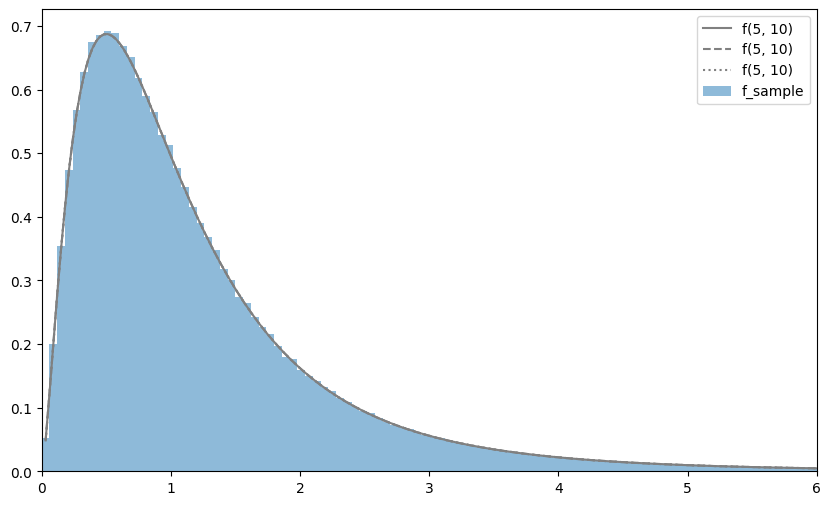

In [166]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv_true = stats.f(n1, n2)
xs = np.linspace(0, 6, 200)[1:]
for n, ln in zip([3, 5, 10], linestyles):
    rv = stats.f(n1, 10)
    ax.plot(xs, rv.pdf(xs), label=f'f({n1}, 10)', ls=ln, color='gray')
ax.hist(f_sample, bins=100, range=(0, 6), density=True, alpha=0.5, label='f_sample')
ax.legend()
ax.set_xlim(0, 6)
plt.show()

# 표본평균의 분포

기대값 = 1, 분산 = 2 인 표본평균, 각 표본의 개수는 10개

In [167]:
mean = 1
var = 2
rv = stats.norm(mean, np.sqrt(var))

In [168]:
n = 10
sample_size = int(1e6)

In [169]:
Xs_sample = rv.rvs((n, sample_size))

In [170]:
sample_mean = np.mean(Xs_sample, axis=0)

In [171]:
np.mean(sample_mean), np.var(sample_mean)

(np.float64(1.0005881515373352), np.float64(0.19998933798412832))

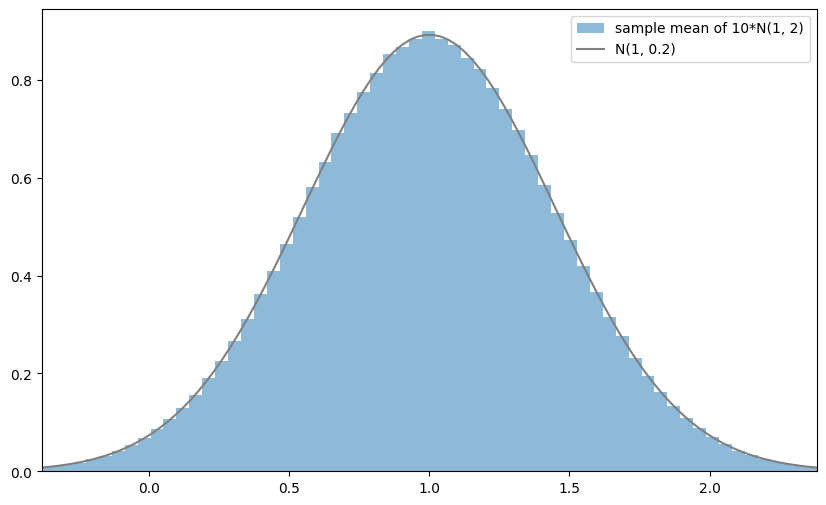

In [172]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
rv_true = stats.norm(mean, np.sqrt(var/n))
xs = np.linspace(rv_true.isf(0.999), rv_true.isf(0.001), 100)
ax.hist(sample_mean, bins=100, density=True,
        alpha=0.5, label='sample mean of 10*N(1, 2)')
ax.plot(xs, rv_true.pdf(xs), label='N(1, 0.2)', color='gray')
ax.legend()
ax.set_xlim(rv_true.isf(0.999), rv_true.isf(0.001))
plt.show()

# 독립동일분포

중심극한정리

대수의 법칙

In [180]:
!ls

drive  sample_data


In [174]:
df = pd.read_csv('./drive/MyDrive/data/ch4_scores400.csv')

In [175]:
scores = np.array(df['score'])

In [176]:
p_mean = np.mean(scores)
p_var = np.var(scores)

In [177]:
p_var, p_mean

(np.float64(206.6691), np.float64(69.53))

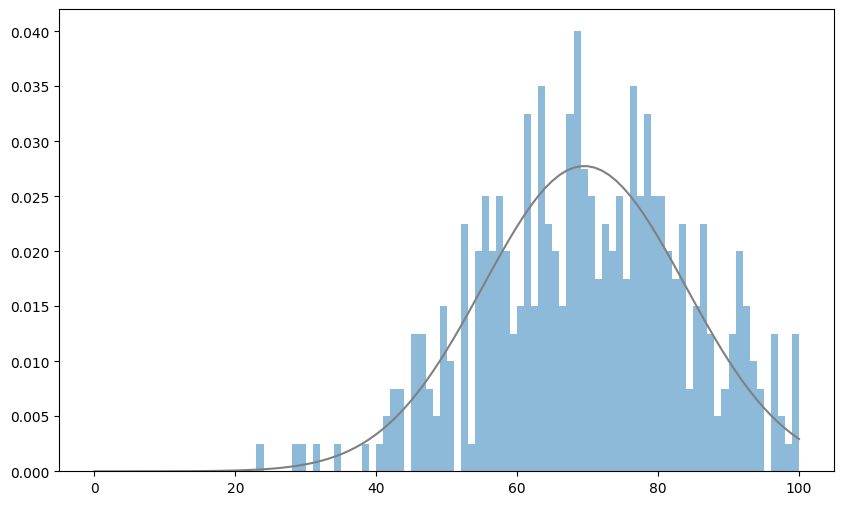

In [178]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
xs = np.arange(101)
rv = stats.norm(p_mean, np.sqrt(p_var))
ax.plot(xs, rv.pdf(xs), color='gray')
ax.hist(scores, bins=100, density=True, alpha=0.5, range=(0, 100))
plt.show()

In [181]:
np.random.seed(0)
n = 20
sample = np.random.choice(scores, n)
sample

array([49, 60, 72, 86, 52, 61, 77, 91, 80, 56, 69, 67, 90, 56, 75, 79, 60,
       79, 68, 81])

In [182]:
np.random.seed(1111)
n_samples = 10000
samples = np.random.choice(scores, (n_samples, n))

In [183]:
samples[41].shape

(20,)

# 점추정

모수를 하나의 수치로 추정 = 점추정

In [196]:
# 표본 5개의 평균값
for i in range(5):
    s_mean = np.mean(samples[i])
    print(f'{i+1}번째 표본평균: {s_mean:.3f}')

1번째 표본평균: 67.000
2번째 표본평균: 72.850
3번째 표본평균: 69.200
4번째 표본평균: 64.450
5번째 표본평균: 72.650


unbiasedness(불편성) = 추정량의 기댓값이 추정하려는 모수가 되는 성질을 의미

불편성을 가진 추정량을 불편추정량이라 한다.

In [203]:
sample_means = np.mean(samples, axis=1)
np.mean(sample_means)

np.float64(69.53799999999998)

표본평균은 모평균의 불편추정량이 된다.

In [195]:
s_mean = np.mean(sample)
s_mean

np.float64(70.4)

## 모분산의 점추정
표본분산이 불편추정량이 되는지 알아보기

In [200]:
samples

array([[ 68,  75,  91, ...,  72,  57,  59],
       [ 97,  55,  61, ...,  65,  73,  71],
       [ 78,  67,  43, ...,  76,  62,  71],
       ...,
       [ 72,  87,  84, ...,  65,  59,  87],
       [ 54,  74,  69, ...,  69,  97,  72],
       [ 78,  57,  85, ...,  68, 100,  94]])

In [197]:
for i in range(5):
    s_var = np.var(samples[i])
    print(f'{i+1}번째 표본분산: {s_var:.3f}')

1번째 표본분산: 116.800
2번째 표본분산: 162.928
3번째 표본분산: 187.060
4번째 표본분산: 149.148
5번째 표본분산: 111.528


In [199]:
# 모분산
p_var

np.float64(206.6691)

In [202]:
# 10000개의 기댓값
samples_vars = np.var(samples, axis=1)
np.mean(samples_vars)

np.float64(196.34417850000003)

In [204]:
sample_u_vars = np.var(samples, axis=1, ddof=1)
np.mean(sample_u_vars)

np.float64(206.67808263157895)

In [205]:
np.var(np.random.choice(scores, int(1e6)), ddof=1)

np.float64(206.4801794340634)